In [11]:
# Import core libraries
import os

os.makedirs("outputs", exist_ok=True)
os.makedirs("models", exist_ok=True)
import warnings
warnings.filterwarnings("ignore")  # keep notebook output clean

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent visual style for all plots in this notebook
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

from sklearn.datasets import load_breast_cancer

# Load the dataset object (contains data, target, feature_names, target_names, DESCR)
raw_data = load_breast_cancer()

print("Type of object returned:", type(raw_data))
print("Available keys:", raw_data.keys())


Type of object returned: <class 'sklearn.utils._bunch.Bunch'>
Available keys: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [12]:
# Convert into a Pandas DataFrame for easier exploration
df = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)

# Add the target column (0 = malignant, 1 = benign)
df["target"] = raw_data.target

print("Dataset shape (rows, columns):", df.shape)
df.head()


Dataset shape (rows, columns): (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [13]:
# Show all feature (column) names
print("Total number of feature columns:", len(raw_data.feature_names))
print("\nFeature columns:\n")
for i, col in enumerate(raw_data.feature_names, 1):
    print(f"{i:2d}. {col}")


Total number of feature columns: 30

Feature columns:

 1. mean radius
 2. mean texture
 3. mean perimeter
 4. mean area
 5. mean smoothness
 6. mean compactness
 7. mean concavity
 8. mean concave points
 9. mean symmetry
10. mean fractal dimension
11. radius error
12. texture error
13. perimeter error
14. area error
15. smoothness error
16. compactness error
17. concavity error
18. concave points error
19. symmetry error
20. fractal dimension error
21. worst radius
22. worst texture
23. worst perimeter
24. worst area
25. worst smoothness
26. worst compactness
27. worst concavity
28. worst concave points
29. worst symmetry
30. worst fractal dimension


In [14]:
# Show target class names and their numeric encoding
print("Target classes (numeric -> label):")
for i, name in enumerate(raw_data.target_names):
    print(f"  {i} -> {name}")

print("\nIMPORTANT: In this dataset, 0 = malignant and 1 = benign.")
print("This is the opposite of what many people instinctively assume, so we'll be careful with it.")


Target classes (numeric -> label):
  0 -> malignant
  1 -> benign

IMPORTANT: In this dataset, 0 = malignant and 1 = benign.
This is the opposite of what many people instinctively assume, so we'll be careful with it.


In [15]:
# Print a short excerpt of the official dataset description (from sklearn)
print(raw_data.DESCR[:1500])


.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

---
# 2. Exploratory Data Analysis (EDA)

In this section we explore the dataset in detail to understand its structure, quality, and the relationships between features and the target variable.


## 2.1 Missing Values Check

In [16]:
# Check for missing/null values in every column
missing_values = df.isnull().sum()
print("Missing values per column:\n")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found in any column. ")


Missing values per column:

No missing values found in any column. 


**Finding:** The Wisconsin Breast Cancer dataset has **zero missing values**. This is one reason it's a popular beginner-friendly dataset — we can skip imputation and go straight into analysis and modeling.

## 2.2 Duplicate Values Check

In [17]:
# Check for fully duplicated rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0


**Finding:** There are no duplicate rows in this dataset, so we don't need to drop anything for this reason either.

## 2.3 Class Distribution

In [18]:
# Map numeric targets to readable labels for plotting
df["diagnosis"] = df["target"].map({0: "Malignant", 1: "Benign"})

class_counts = df["diagnosis"].value_counts()
print(class_counts)
print("\nPercentage distribution:")
print((class_counts / len(df) * 100).round(2))


diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

Percentage distribution:
diagnosis
Benign       62.74
Malignant    37.26
Name: count, dtype: float64


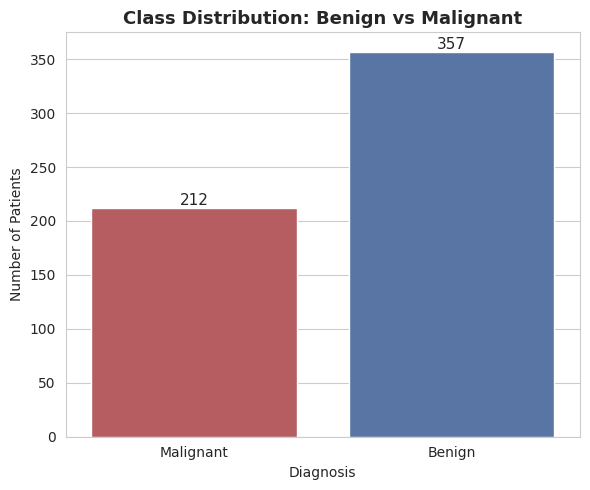

In [19]:
# Plot class distribution
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df, x="diagnosis", hue="diagnosis",
                    palette={"Benign": "#4C72B0", "Malignant": "#C44E52"}, legend=False)
plt.title("Class Distribution: Benign vs Malignant", fontsize=13, fontweight="bold")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")

# Annotate bar counts
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.savefig("outputs/class_distribution.png", dpi=150)
plt.show()


## 2.4 Statistical Summary

In [20]:
# Statistical summary of all numeric features
df.describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## 2.5 Correlation Heatmap

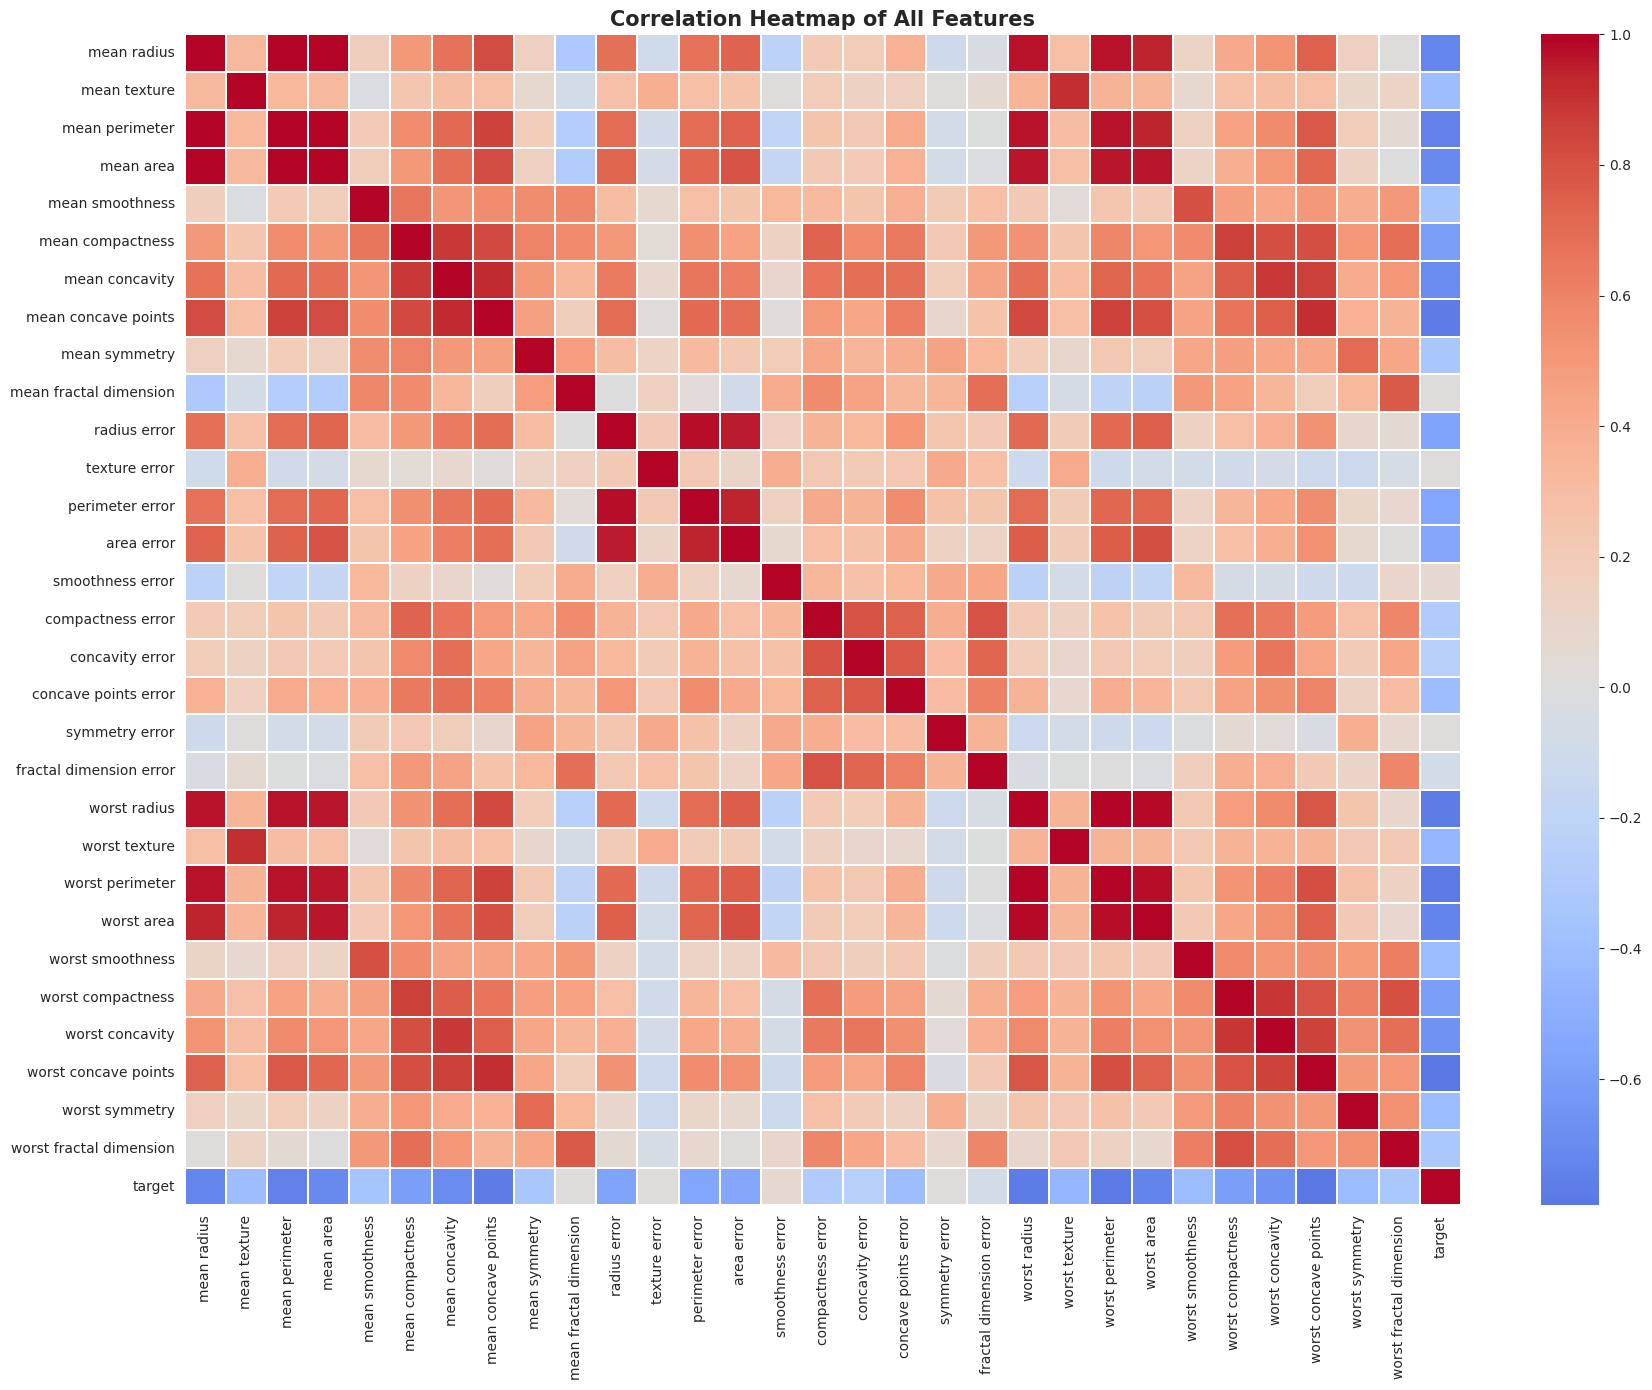

In [21]:
# Compute correlation matrix (excluding the non-numeric 'diagnosis' column)
corr_matrix = df.drop(columns=["diagnosis"]).corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, linewidths=0.3, center=0)
plt.title("Correlation Heatmap of All Features", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/correlation_heatmap_full.png", dpi=150)
plt.show()


In [22]:
# Top features most correlated with the target (in absolute value)
target_corr = corr_matrix["target"].drop("target").sort_values(key=abs, ascending=False)
print("Top 10 features most correlated with target (diagnosis):\n")
print(target_corr.head(10))


Top 10 features most correlated with target (diagnosis):

worst concave points   -0.793566
worst perimeter        -0.782914
mean concave points    -0.776614
worst radius           -0.776454
mean perimeter         -0.742636
worst area             -0.733825
mean radius            -0.730029
mean area              -0.708984
mean concavity         -0.696360
worst concavity        -0.659610
Name: target, dtype: float64


## 2.6 Histograms of Key Features

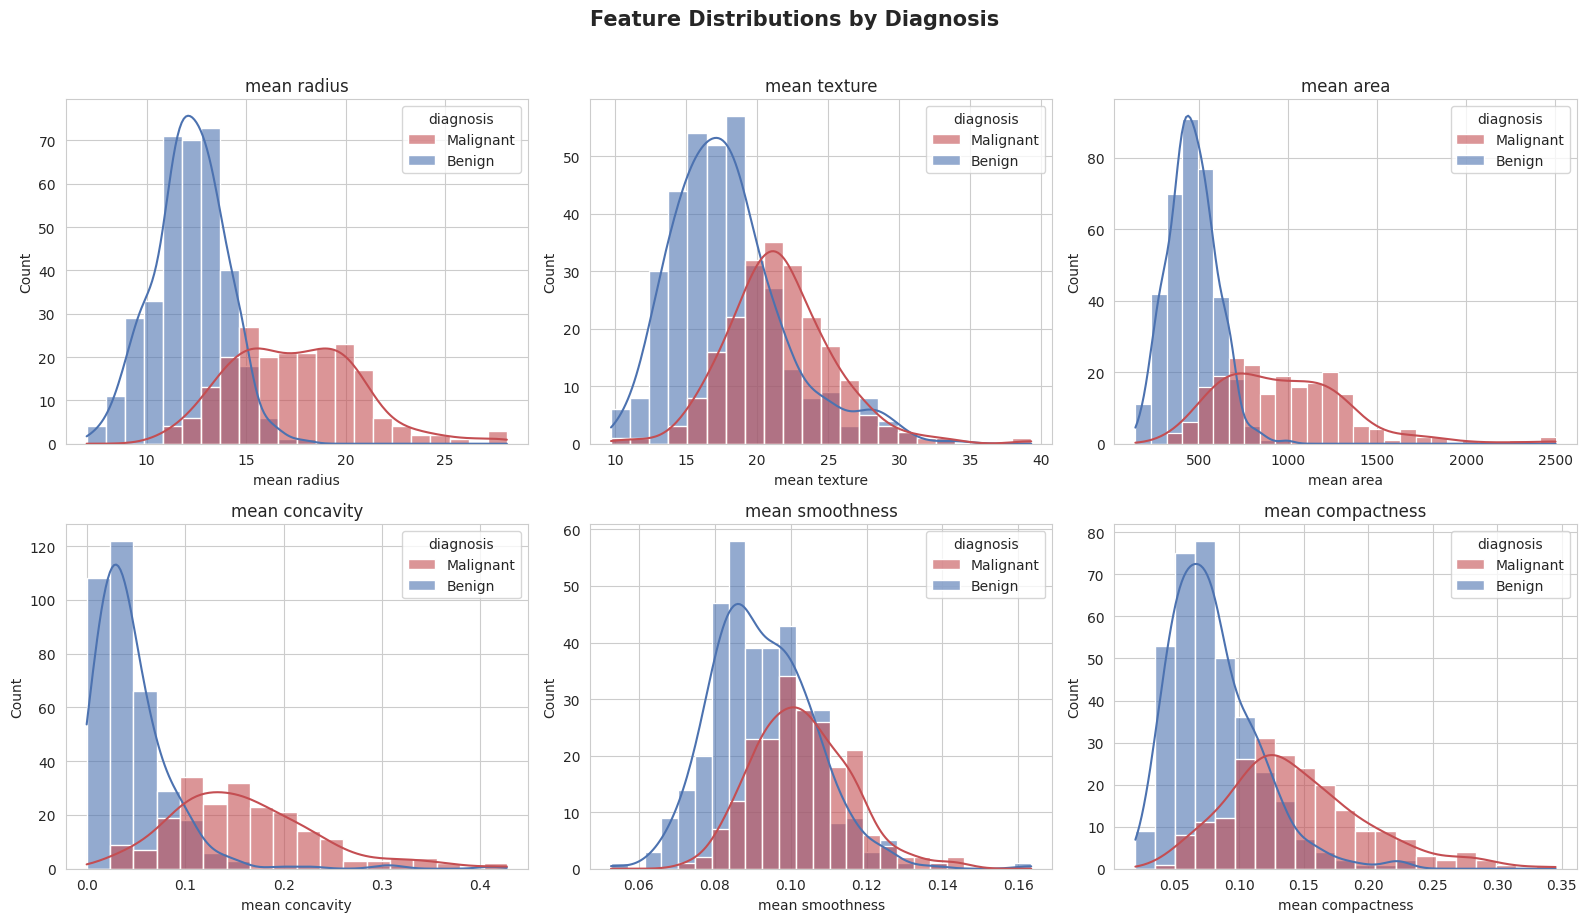

In [23]:
# Histograms for a few clinically important features, split by diagnosis
key_features = ["mean radius", "mean texture", "mean area", "mean concavity", "mean smoothness", "mean compactness"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    sns.histplot(data=df, x=feature, hue="diagnosis", kde=True, ax=axes[i],
                 palette={"Benign": "#4C72B0", "Malignant": "#C44E52"}, alpha=0.6)
    axes[i].set_title(feature)

plt.suptitle("Feature Distributions by Diagnosis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/histograms_key_features.png", dpi=150)
plt.show()


## 2.7 Boxplots of Key Features

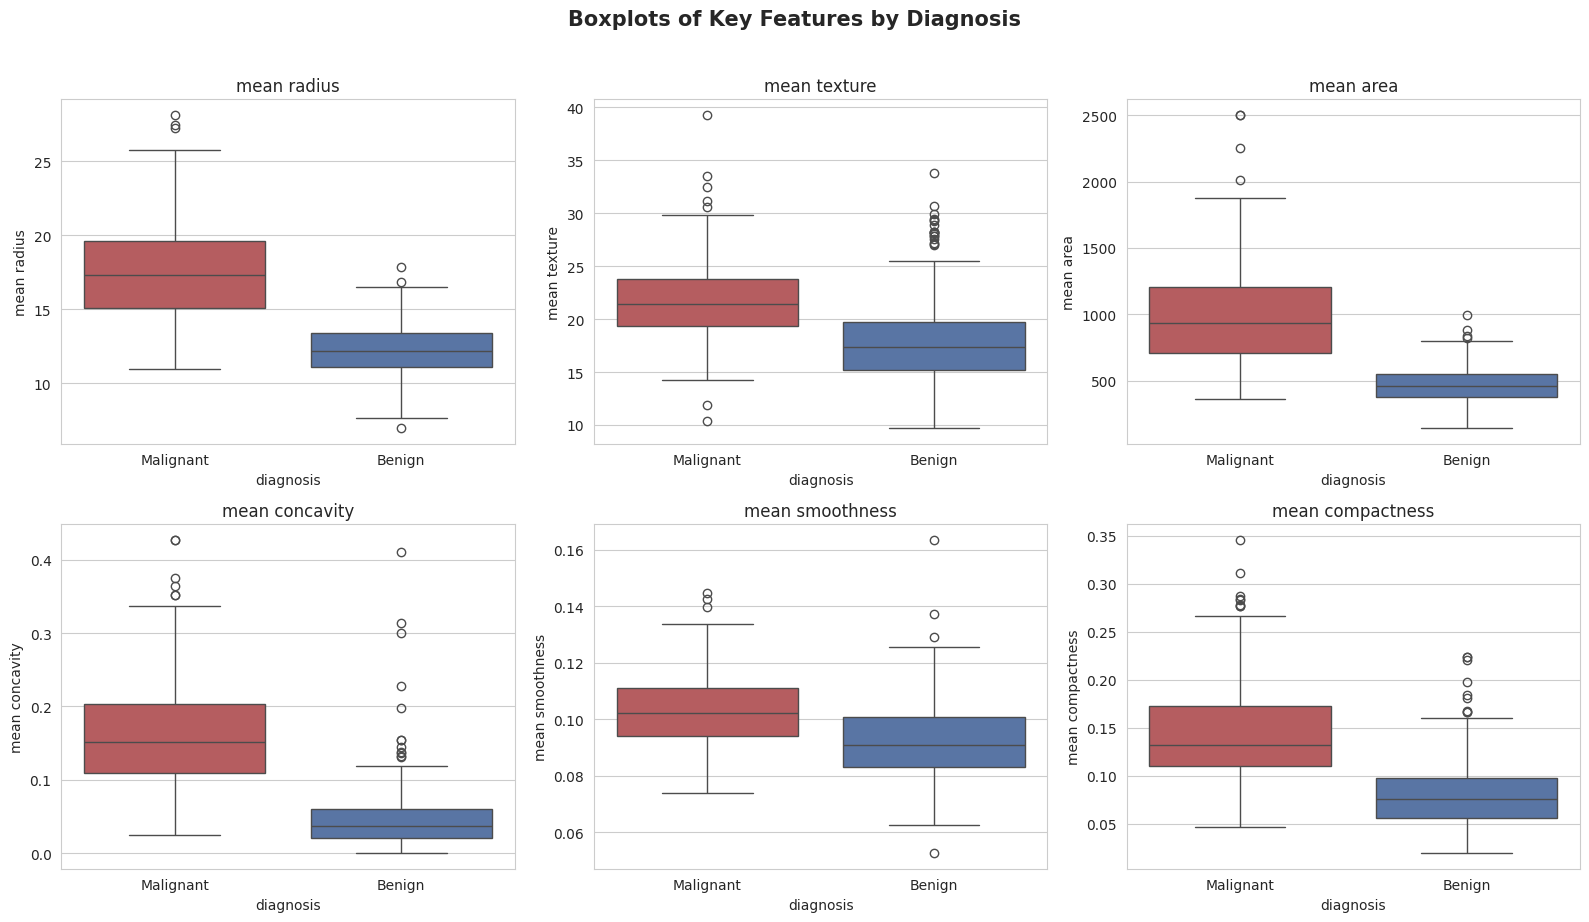

In [24]:
# Boxplots help us see the spread, median and outliers for each class
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    sns.boxplot(data=df, x="diagnosis", y=feature, hue="diagnosis", ax=axes[i],
                palette={"Benign": "#4C72B0", "Malignant": "#C44E52"}, legend=False)
    axes[i].set_title(feature)

plt.suptitle("Boxplots of Key Features by Diagnosis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/boxplots_key_features.png", dpi=150)
plt.show()


## 2.8 Pairplot of Selected Important Features

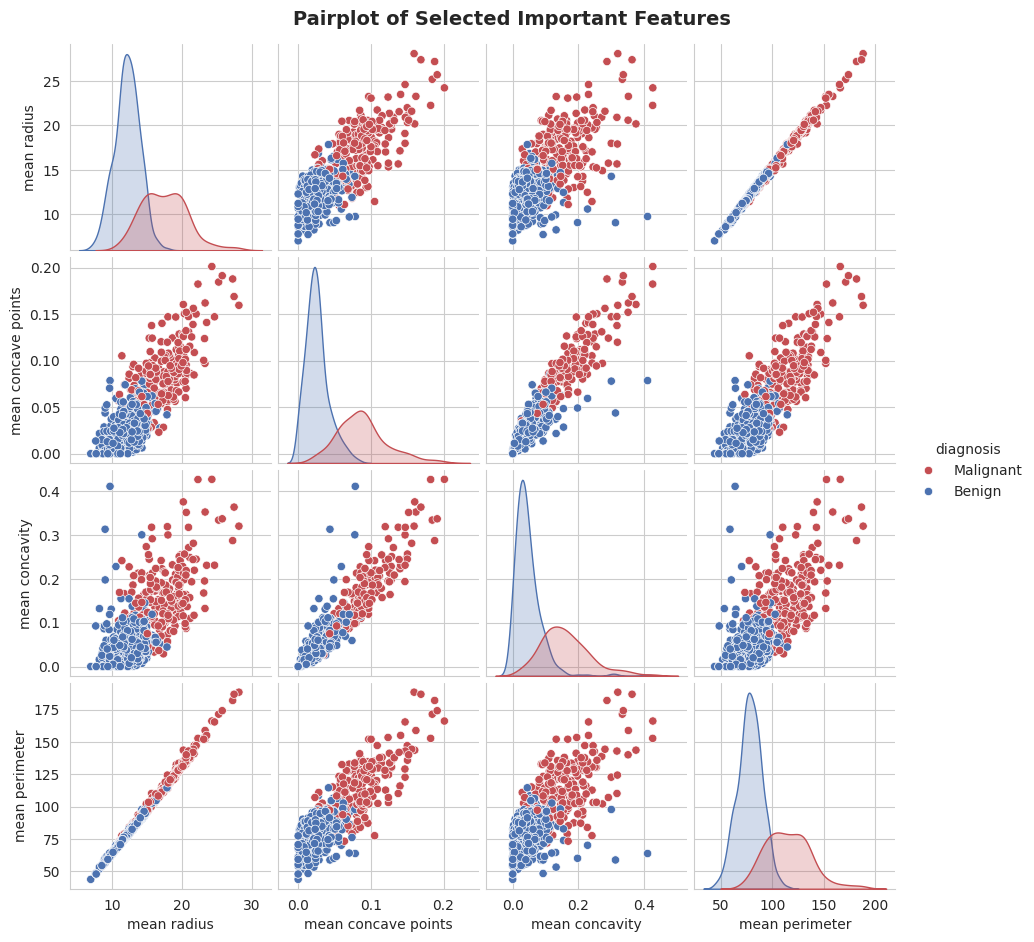

In [25]:
# Pairplot on a few of the most informative features (using a subset of rows for speed)
pairplot_features = ["mean radius", "mean concave points", "mean concavity", "mean perimeter", "diagnosis"]

sns.pairplot(df[pairplot_features], hue="diagnosis",
             palette={"Benign": "#4C72B0", "Malignant": "#C44E52"}, diag_kind="kde", height=2.3)
plt.suptitle("Pairplot of Selected Important Features", y=1.02, fontsize=14, fontweight="bold")
plt.savefig("outputs/pairplot_key_features.png", dpi=150)
plt.show()


---
# 3. Data Preprocessing

Now that we understand the data, we prepare it for modeling.


## 3.1 Re-check Missing Values

In [26]:
# Final confirmation before modeling
print("Total missing values in dataset:", df.drop(columns=["diagnosis"]).isnull().sum().sum())


Total missing values in dataset: 0


## 3.2 Splitting Features and Target

In [27]:
# Separate features (X) from target (y).
# We drop both 'target' (numeric label) and 'diagnosis' (text label we added for EDA)
X = df.drop(columns=["target", "diagnosis"])
y = df["target"]   # 0 = malignant, 1 = benign

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (569, 30)
Target shape: (569,)


## 3.3 Train-Test Split (80-20)

In [28]:
from sklearn.model_selection import train_test_split

# 80% training data, 20% testing data.
# stratify=y ensures both sets keep the same benign/malignant ratio as the full dataset.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size :", X_test.shape)

print("\nClass balance check:")
print("Train:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest:\n", y_test.value_counts(normalize=True).round(3))


Training set size: (455, 30)
Testing set size : (114, 30)

Class balance check:
Train:
 target
1    0.626
0    0.374
Name: proportion, dtype: float64

Test:
 target
1    0.632
0    0.368
Name: proportion, dtype: float64


## 3.4 Feature Scaling with StandardScaler

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data only, then transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling (first row, first 5 features):\n", X_train.iloc[0, :5].values)
print("\nAfter scaling (first row, first 5 features):\n", X_train_scaled[0, :5])


Before scaling (first row, first 5 features):
 [1.032e+01 1.635e+01 6.531e+01 3.249e+02 9.434e-02]

After scaling (first row, first 5 features):
 [-1.07200079 -0.6584246  -1.0880801  -0.93927364 -0.13593988]


---
# 4. Model Building

We will train and compare **six** core classification models:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Support Vector Machine (SVM)
5. K-Nearest Neighbors (KNN)
6. Naive Bayes




In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Try to import XGBoost; if unavailable, skip it safely instead of crashing
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost is available and will be included in the comparison.")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost is NOT installed in this environment. It will be skipped safely.")
    print("(To include it, run: pip install xgboost)")


XGBoost is available and will be included in the comparison.


In [31]:
# Define all models in a dictionary: name -> model instance
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),   # probability=True needed for ROC-AUC
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)

print("Models to train:", list(models.keys()))


Models to train: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'KNN', 'Naive Bayes', 'XGBoost']


In [32]:
# Train every model on the scaled training data
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")


Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest
Trained: SVM
Trained: KNN
Trained: Naive Bayes
Trained: XGBoost


In [33]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

def evaluate_model(model, X_test, y_test):
    """Computes all key evaluation metrics for a single trained model."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # probability of class 1 (benign)

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        # pos_label=0 -> metrics calculated for the MALIGNANT class specifically
        "Precision (Malignant)": precision_score(y_test, y_pred, pos_label=0),
        "Recall (Malignant)": recall_score(y_test, y_pred, pos_label=0),
        "F1 Score (Malignant)": f1_score(y_test, y_pred, pos_label=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "Confusion Matrix": confusion_matrix(y_test, y_pred),
        "Classification Report": classification_report(y_test, y_pred, target_names=["malignant", "benign"]),
        "y_pred": y_pred,
        "y_proba": y_proba,
    }
    return metrics


In [34]:
# Evaluate every trained model and store results
results = {}

for name, model in trained_models.items():
    results[name] = evaluate_model(model, X_test_scaled, y_test)
    print(f"\n{'='*70}\nModel: {name}\n{'='*70}")
    print(results[name]["Classification Report"])
    print("Confusion Matrix:\n", results[name]["Confusion Matrix"])
    print(f"ROC-AUC: {results[name]['ROC-AUC']:.4f}")



Model: Logistic Regression
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
 [[41  1]
 [ 1 71]]
ROC-AUC: 0.9954

Model: Decision Tree
              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114

Confusion Matrix:
 [[39  3]
 [ 7 65]]
ROC-AUC: 0.9157

Model: Random Forest
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

  

---
# 6. Model Comparison

We now bring all model results together into a single comparison table and chart.


In [35]:
# Build a clean comparison DataFrame
comparison_rows = []
for name, res in results.items():
    comparison_rows.append({
        "Model": name,
        "Accuracy": res["Accuracy"],
        "Precision (Malignant)": res["Precision (Malignant)"],
        "Recall (Malignant)": res["Recall (Malignant)"],
        "F1 Score (Malignant)": res["F1 Score (Malignant)"],
        "ROC-AUC": res["ROC-AUC"],
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by=["Recall (Malignant)", "ROC-AUC", "F1 Score (Malignant)"], ascending=False
).reset_index(drop=True)

comparison_df


,Model,Accuracy,Precision (Malignant),Recall (Malignant),F1 Score (Malignant),ROC-AUC
0,Logistic Regression,0.982456,0.976190,0.976190,0.976190,0.995370
1,SVM,0.982456,0.976190,0.976190,0.976190,0.995040
2,Random Forest,0.956140,0.951220,0.928571,0.939759,0.993882
3,KNN,0.956140,0.951220,0.928571,0.939759,0.978836
4,Decision Tree,0.912281,0.847826,0.928571,0.886364,0.915675
5,XGBoost,0.956140,0.974359,0.904762,0.938272,0.990079
6,Naive Bayes,0.929825,0.904762,0.904762,0.904762,0.986772


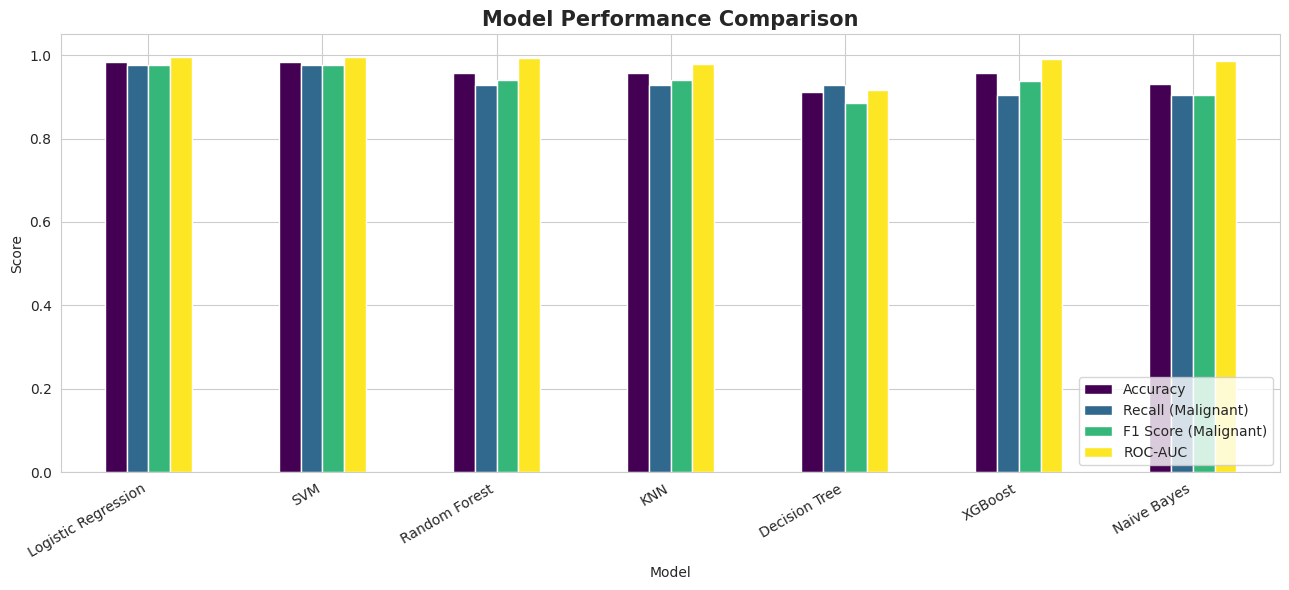

In [36]:
# Plot a grouped bar chart comparing all models across key metrics
metrics_to_plot = ["Accuracy", "Recall (Malignant)", "F1 Score (Malignant)", "ROC-AUC"]
plot_df = comparison_df.set_index("Model")[metrics_to_plot]

ax = plot_df.plot(kind="bar", figsize=(13, 6), colormap="viridis")
plt.title("Model Performance Comparison", fontsize=15, fontweight="bold")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("outputs/model_comparison.png", dpi=150)
plt.show()


In [37]:
# Select the best model based on Recall (Malignant) -> ROC-AUC -> F1 Score, in that priority order
best_model_name = comparison_df.iloc[0]["Model"]
print(f"Best performing model (before tuning): {best_model_name}")
comparison_df.head(1)


Best performing model (before tuning): Logistic Regression


,Model,Accuracy,Precision (Malignant),Recall (Malignant),F1 Score (Malignant),ROC-AUC
0,Logistic Regression,0.982456,0.97619,0.97619,0.97619,0.99537


In [38]:
from sklearn.model_selection import GridSearchCV

top_2_models = comparison_df["Model"].head(2).tolist()
print("Top 2 models selected for tuning:", top_2_models)


Top 2 models selected for tuning: ['Logistic Regression', 'SVM']


In [39]:
# Define hyperparameter grids for each possible model
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver": ["lbfgs"],
    },
    "Decision Tree": {
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10],
        "criterion": ["gini", "entropy"],
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5],
    },
    "SVM": {
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", "auto"],
        "kernel": ["rbf", "linear"],
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9, 11],
        "weights": ["uniform", "distance"],
    },
    "Naive Bayes": {
        "var_smoothing": np.logspace(0, -9, num=20),
    },
}

if XGBOOST_AVAILABLE:
    param_grids["XGBoost"] = {
        "n_estimators": [100, 200],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.1, 0.2],
    }

# Fresh, untrained base models to tune (so GridSearchCV starts clean)
base_models_for_tuning = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
}
if XGBOOST_AVAILABLE:
    base_models_for_tuning["XGBoost"] = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)


In [40]:
# Run GridSearchCV on the top 2 models
tuned_models = {}
tuning_summary = []

for name in top_2_models:
    print(f"\nTuning {name} ...")
    grid = GridSearchCV(
        estimator=base_models_for_tuning[name],
        param_grid=param_grids[name],
        scoring="recall_macro",
        cv=5,
        n_jobs=-1,
    )
    grid.fit(X_train_scaled, y_train)
    tuned_models[name] = grid.best_estimator_

    print(f"  Best Params: {grid.best_params_}")
    print(f"  Best CV Recall (macro): {grid.best_score_:.4f}")

    tuning_summary.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Best CV Recall (macro)": grid.best_score_
    })

pd.DataFrame(tuning_summary)



Tuning Logistic Regression ...
  Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
  Best CV Recall (macro): 0.9771

Tuning SVM ...
  Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
  Best CV Recall (macro): 0.9747


,Model,Best Params,Best CV Recall (macro)
0,Logistic Regression,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.977090
1,SVM,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}",0.974716


In [41]:
# Re-evaluate the tuned models on the held-out test set
tuned_results = {}
for name, model in tuned_models.items():
    tuned_results[name] = evaluate_model(model, X_test_scaled, y_test)
    print(f"\n[TUNED] {name}")
    print(tuned_results[name]["Classification Report"])



[TUNED] Logistic Regression
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


[TUNED] SVM
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [42]:
# Select the final model
final_model_name = max(
    tuned_results,
    key=lambda n: (
        tuned_results[n]["Recall (Malignant)"],
        tuned_results[n]["ROC-AUC"],
        tuned_results[n]["F1 Score (Malignant)"],
    )
)

final_model = tuned_models[final_model_name]
final_result = tuned_results[final_model_name]

print(f"FINAL SELECTED MODEL: {final_model_name}\n")
print(final_result["Classification Report"])


FINAL SELECTED MODEL: Logistic Regression

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 8.1 Save the Final Model and Scaler

In [43]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(final_model, "models/breast_cancer_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(list(X.columns), "models/feature_names.pkl")
joblib.dump(final_model_name, "models/model_name.pkl")

print("Saved:")
print("  models/breast_cancer_model.pkl")
print("  models/scaler.pkl")
print("  models/feature_names.pkl")
print("  models/model_name.pkl")


Saved:
  models/breast_cancer_model.pkl
  models/scaler.pkl
  models/feature_names.pkl
  models/model_name.pkl


## 8.2 Sample Prediction Function

In [44]:
def predict_tumor(feature_values, model=final_model, scaler=scaler, feature_names=list(X.columns)):
    """
    Predicts Benign / Malignant for a single sample.

    Parameters
    ----------
    feature_values : list or array-like of length 30
        Feature values in the SAME order as `feature_names`.

    Returns
    -------
    dict with prediction label and class probabilities.

    SAFETY NOTE: This is an academic prediction only -- NOT medical advice.
    """
    feature_values = np.array(feature_values, dtype=float).reshape(1, -1)
    feature_df = pd.DataFrame(feature_values, columns=feature_names)

    scaled = scaler.transform(feature_df)
    pred = model.predict(scaled)[0]            # 0 = malignant, 1 = benign
    proba = model.predict_proba(scaled)[0]      # [P(malignant), P(benign)]

    label = "Benign" if pred == 1 else "Malignant"

    return {
        "prediction": label,
        "probability_malignant": float(proba[0]),
        "probability_benign": float(proba[1]),
    }


In [45]:
# Demo: predict using a real sample from the test set
sample_index = 0
sample_features = X_test.iloc[sample_index].values
true_label = "Benign" if y_test.iloc[sample_index] == 1 else "Malignant"

prediction_result = predict_tumor(sample_features)

print("DEMO PREDICTION (using a real sample from the held-out test set)")
print("-" * 60)
print(f"True label       : {true_label}")
print(f"Predicted label  : {prediction_result['prediction']}")
print(f"P(Malignant)     : {prediction_result['probability_malignant']*100:.2f}%")
print(f"P(Benign)        : {prediction_result['probability_benign']*100:.2f}%")
print("\nReminder: This is an academic ML prediction, NOT medical advice.")
print("Always consult a qualified medical professional for real diagnosis.")


DEMO PREDICTION (using a real sample from the held-out test set)
------------------------------------------------------------
True label       : Malignant
Predicted label  : Malignant
P(Malignant)     : 100.00%
P(Benign)        : 0.00%

Reminder: This is an academic ML prediction, NOT medical advice.
Always consult a qualified medical professional for real diagnosis.


---
# 9. Final Visualizations

We generate the key visualizations for our **final selected model**: Confusion Matrix, ROC Curve, and Feature Importance (if supported by the model).


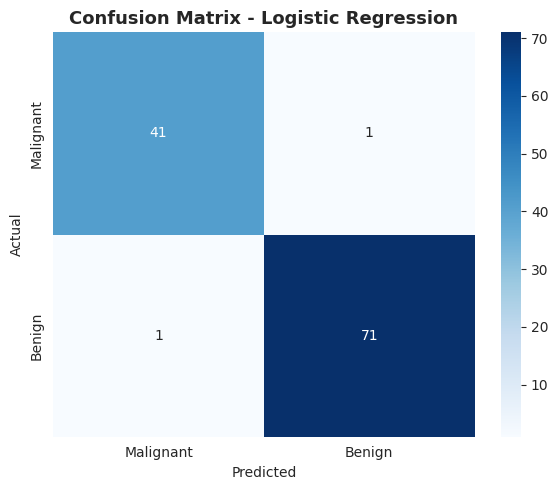

In [46]:
# Confusion Matrix for the final model
plt.figure(figsize=(6, 5))
sns.heatmap(
    final_result["Confusion Matrix"], annot=True, fmt="d", cmap="Blues",
    xticklabels=["Malignant", "Benign"], yticklabels=["Malignant", "Benign"]
)
plt.title(f"Confusion Matrix - {final_model_name}", fontsize=13, fontweight="bold")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=150)
plt.show()


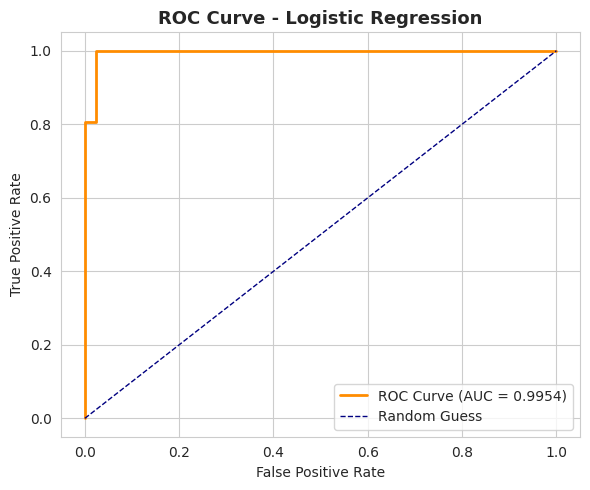

In [47]:
# ROC Curve for the final model
fpr, tpr, _ = roc_curve(y_test, final_result["y_proba"])
auc_score = final_result["ROC-AUC"]

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {final_model_name}", fontsize=13, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("outputs/roc_curve.png", dpi=150)
plt.show()


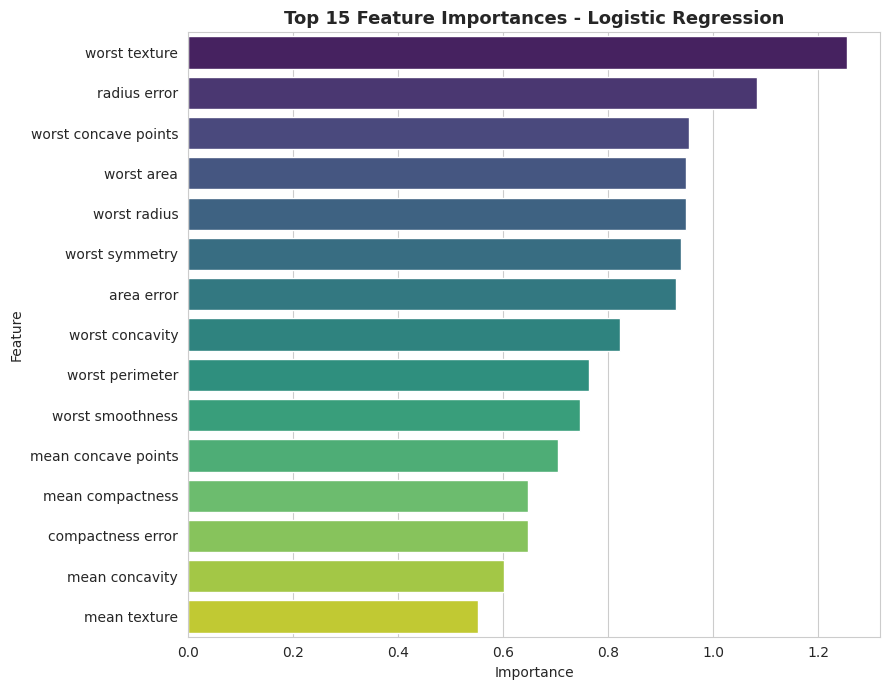

In [48]:
# Feature Importance plot (if supported by the final model)
importances = None

if hasattr(final_model, "feature_importances_"):
    importances = final_model.feature_importances_
elif hasattr(final_model, "coef_"):
    importances = np.abs(final_model.coef_[0])

if importances is not None:
    feat_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False).head(15)

    plt.figure(figsize=(9, 7))
    sns.barplot(data=feat_df, x="Importance", y="Feature", hue="Feature", palette="viridis", legend=False)
    plt.title(f"Top 15 Feature Importances - {final_model_name}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("outputs/feature_importance.png", dpi=150)
    plt.show()
else:
    print(f"{final_model_name} does not expose feature_importances_ or coef_, skipping this plot.")
